<a href="https://colab.research.google.com/github/pius928/BIT4133-NLP-DeepLearning-Logbook/blob/main/week_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 19.8 MB/s eta 0:00:00


In [22]:
pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.4.2
    Uninstalling click-8.4.2:
      Successfully uninstalled click-8.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.20.1 requires click>=8.4.0, but you have click 8.1.8 which is incompatible.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
typer 0.25.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [2]:
import librosa
import speech_recognition as sr
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [23]:
from gtts import gTTS
import os

In [3]:
audio, sample_rate = librosa.load("speech.wav")

print("Sample Rate:", sample_rate)
print("Audio Length:", len(audio))

/tmp/ipykernel_771/3308591371.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load("speech.wav")
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'speech.wav'

In [4]:
import numpy as np
import soundfile as sf

# Generate a 5-second sine wave at 440 Hz
sample_rate_dummy = 22050  # Common sample rate
duration = 5  # seconds
frequency = 440  # Hz (A4 note)

t = np.linspace(0, duration, int(sample_rate_dummy * duration), endpoint=False)
sine_wave = 0.5 * np.sin(2 * np.pi * frequency * t)

# Save the dummy audio to a WAV file
dummy_audio_file = 'dummy_speech.wav'
sf.write(dummy_audio_file, sine_wave, sample_rate_dummy)

print(f"Created a dummy audio file: {dummy_audio_file}")

Created a dummy audio file: dummy_speech.wav


In [5]:
# Now load the dummy audio file
audio, sample_rate = librosa.load("dummy_speech.wav")

print("Sample Rate:", sample_rate)
print("Audio Length:", len(audio))

Sample Rate: 22050
Audio Length: 110250


In [20]:
r = sr.Recognizer()
# The audio data loaded by librosa is a numpy array.
# SpeechRecognition expects a specific AudioData format.
# We need to create an AudioData object from the numpy array.

# Create an AudioData object from the librosa audio array
# This conversion assumes the audio is mono (which our dummy audio is)
# and uses the sample rate provided by librosa. If the audio had
# multiple channels, further processing would be needed.

# For `sr.AudioData`, the 'frame_data' should be raw bytes.
# We convert the float32 array to bytes. This is a common approach
# for speech_recognition with librosa.

# Ensure audio is float32 and convert to bytes
# Multiplying by 32767 to scale to int16 range, then converting to bytes
# The exact scaling and byte representation might need fine-tuning depending on the recognizer backend

# A more direct and robust way is to save the numpy array to a temporary WAV
# file and then load it with SpeechRecognition's AudioFile.

import tempfile
import os

# Save the librosa audio to a temporary WAV file
with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp_wav_file:
    sf.write(tmp_wav_file.name, audio, sample_rate)
    temp_audio_path = tmp_wav_file.name

print(f"Temporary audio file created at: {temp_audio_path}")

with sr.AudioFile(temp_audio_path) as source:
    # listen for the data (load audio to memory)
    audio_data = r.record(source)
    # recognize (convert from speech to text)
    try:
        text = r.recognize_google(audio_data)
        print("Recognized Text:", text)
    except sr.UnknownValueError:
        print("Speech Recognition could not understand audio")
    except sr.RequestError as e:
        print(f"Could not request results from Google Speech Recognition service; {e}")

# Clean up the temporary file (commenting this out so the file persists)
# os.remove(temp_audio_path)
# print(f"Temporary audio file removed: {temp_audio_path}")

Temporary audio file created at: /tmp/tmpxasv692n.wav
Speech Recognition could not understand audio


In [8]:
!pip install pydub

In [13]:
from pydub import AudioSegment
from pydub.playback import play

# Create an AudioSegment from the numpy array
# pydub works with samples in integer format, so convert float to int16
# and scale to the maximum value for int16 (32767)
scaled_sine_wave = (sine_wave * 32767).astype(np.int16)

# Create an AudioSegment. Parameters:
# - data: The audio data (bytes, array, etc.)
# - sample_width: 2 bytes for int16
# - frame_rate: the sample rate
# - channels: 1 for mono
audio_segment = AudioSegment(scaled_sine_wave.tobytes(),
                             frame_rate=sample_rate_dummy,
                             sample_width=scaled_sine_wave.dtype.itemsize,
                             channels=1)

print("Playing the generated sine wave...")
play(audio_segment)
print("Finished playing.")

Playing the generated sine wave...
Finished playing.


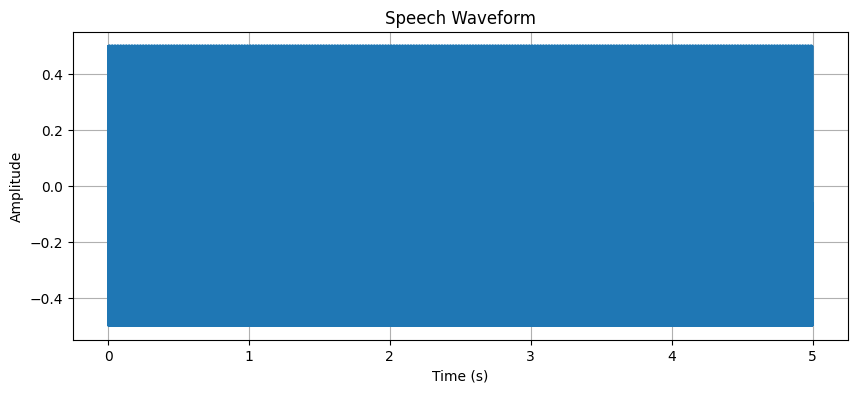

In [15]:
import numpy as np

plt.figure(figsize=(10,4))

# Create a time array for the x-axis
# The audio variable has length 'len(audio)' and sample rate 'sample_rate'
time = np.linspace(0, len(audio) / sample_rate, num=len(audio))

plt.plot(time, audio)
plt.title("Speech Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True) # Add grid for better readability
plt.show()

In [16]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=13
)

print(mfcc.shape)

(13, 216)


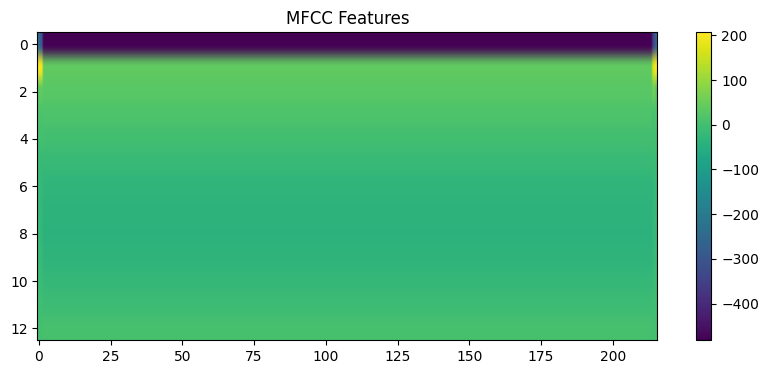

In [17]:
plt.figure(figsize=(10,4))
plt.imshow(mfcc, aspect='auto')
plt.colorbar()
plt.title("MFCC Features")
plt.show()

In [21]:
recognizer = sr.Recognizer()

# Use the temp_audio_path which was created from the dummy audio
with sr.AudioFile(temp_audio_path) as source:
    audio_data = recognizer.record(source)

# Recognize (convert from speech to text)
try:
    text = recognizer.recognize_google(audio_data)
    print("Recognized Text:")
    print(text)
except sr.UnknownValueError:
    print("Speech Recognition could not understand audio")
except sr.RequestError as e:
    print(f"Could not request results from Google Speech Recognition service; {e}")

Speech Recognition could not understand audio


### Speech Recognition with Generated Speech

Now, let's generate some actual speech using a Text-to-Speech (TTS) library and then attempt to recognize it. This will demonstrate how speech recognition works with meaningful audio.

In [26]:
from gtts import gTTS
import os
import tempfile
from pydub import AudioSegment

# Define the text to be converted to speech
text_to_speak = "Hello, this is a test of speech recognition in Google Colab."

# Create a gTTS object
tts = gTTS(text=text_to_speak, lang='en')

# Save the generated speech to a temporary MP3 file first (gTTS default output)
with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as fp_mp3:
    mp3_temp_path = fp_mp3.name
tts.save(mp3_temp_path)

# Convert the temporary MP3 to a WAV file using pydub
with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as fp_wav:
    real_speech_temp_path = fp_wav.name

AudioSegment.from_mp3(mp3_temp_path).export(real_speech_temp_path, format="wav")

# Clean up the temporary MP3 file
os.remove(mp3_temp_path)

print(f"Generated speech (converted to WAV) saved to: {real_speech_temp_path}")

Generated speech (converted to WAV) saved to: /tmp/tmpy_v0bqfj.wav


In [27]:
recognizer = sr.Recognizer()

# Use the newly generated real speech audio file (now in WAV format)
with sr.AudioFile(real_speech_temp_path) as source:
    audio_data_real = recognizer.record(source)

# Recognize (convert from speech to text)
try:
    text_recognized = recognizer.recognize_google(audio_data_real)
    print("Recognized Text:")
    print(text_recognized)
except sr.UnknownValueError:
    print("Speech Recognition could not understand audio")
except sr.RequestError as e:
    print(f"Could not request results from Google Speech Recognition service; {e}")

# Clean up the temporary speech file
os.remove(real_speech_temp_path)
print(f"Temporary speech file removed: {real_speech_temp_path}")

Recognized Text:
hello this is a test of speech recognition in Google collab
Temporary speech file removed: /tmp/tmpy_v0bqfj.wav
